# AlphaFold pLDDT at exon-exon junctions

Does local model confidence (pLDDT) relate to where introns interrupt the
protein? Using `prot2exon` we know, for every protein, exactly which residue
each exon-exon junction falls on. We line those junctions up against the
per-residue pLDDT of the **whole human canonical proteome** from the AlphaFold
Database and ask whether confidence changes near a junction.

Pipeline (each heavy step is cache-aware):

1. Map every canonical ENSP → UniProt accession (Ensembl BioMart r115).
2. Fetch per-residue pLDDT for each canonical protein from AlphaFold DB (v6).
3. Recover exon-exon junction residue positions with `prot2exon`.
4. Average pLDDT as a function of residue distance to the nearest junction.

In [1]:
# Force the inline backend — under `jupyter nbconvert --execute` the
# default sometimes lands on Agg, which prints `<Figure …>` instead of
# the actual PNG. The magic call forces module://matplotlib_inline.backend_inline.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass  # Not in IPython (e.g. plain python REPL); ignore.
import matplotlib as mpl
import matplotlib.pyplot as plt

# Paper-ready figure defaults. Tweaks vs matplotlib's stock style:
#   - Larger fonts (10pt body, 11pt axis labels, 12pt title).
#   - Thinner spines + only-left/-bottom by default (less chartjunk).
#   - Subtle horizontal grid; no vertical grid.
#   - tab10 palette but used sparingly — we override per-plot.
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.titlepad': 10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#e5e7eb',
    'grid.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.frameon': False,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
})

# Colorblind-safe palette (Wong 2011, also used in seaborn's 'colorblind').
COLORS = {
    'prot2exon':   '#0072B2',  # blue
    'ensembldb':   '#009E73',  # bluish green
    'transvar':    '#E69F00',  # orange
    'rest':        '#CC79A7',  # reddish-purple
    'good':        '#009E73',
    'bad':         '#D55E00',  # vermilion (works for colorblind)
    'neutral':     '#56B4E9',
    'highlight':   '#F0E442',
}

import os, json, pickle, time, urllib.parse, urllib.request, urllib.error, subprocess
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

DATA = Path.home() / "Desktop" / "protein2genomic_data"
IDX  = DATA / "human_v115.idx"
MAP  = DATA / "ensp_uniprot_v115.tsv"
PKL  = DATA / "af_plddt.pkl"
WIN, JUNC, CORE_LO, CORE_HI = 30, 1, 6, 15
print("data dir:", DATA)

data dir: /home/goguxor/Desktop/protein2genomic_data


## 1. ENSP → UniProt (BioMart r115)

One canonical protein per gene, with its Swiss-Prot accession — that is the
sequence AlphaFold models.

In [2]:
def pull_ensp_uniprot(out):
    host = "https://www.ensembl.org/biomart/martservice"
    chroms = [str(i) for i in range(1, 23)] + ["X", "Y"]
    def xml(c):
        return ('<?xml version="1.0" encoding="UTF-8"?><!DOCTYPE Query>'
            '<Query virtualSchemaName="default" formatter="TSV" header="0" '
            'uniqueRows="1" count="" datasetConfigVersion="0.6">'
            '<Dataset name="hsapiens_gene_ensembl" interface="default">'
            f'<Filter name="chromosome_name" value="{c}"/>'
            '<Attribute name="ensembl_peptide_id"/>'
            '<Attribute name="uniprotswissprot"/>'
            '<Attribute name="transcript_is_canonical"/></Dataset></Query>')
    rows = {}
    for c in chroms:
        url = host + "?" + urllib.parse.urlencode({"query": xml(c)})
        with urllib.request.urlopen(url, timeout=180) as r:
            for ln in r.read().decode().splitlines():
                f = ln.split("\t")
                if len(f) < 2 or not f[0] or not f[1]:
                    continue
                rows[f[0]] = (f[1], len(f) > 2 and f[2] == "1")
    with open(out, "w") as fh:
        fh.write("protein_id\tuniprot\tis_canonical\n")
        for e, (u, c) in rows.items():
            fh.write(f"{e}\t{u}\t{int(c)}\n")
    return len(rows)

if not MAP.exists():
    pull_ensp_uniprot(MAP)
m = pd.read_csv(MAP, sep="\t")
canon = m[(m.is_canonical == 1) & m.uniprot.notna()].drop_duplicates("protein_id")
print(f"{len(canon):,} canonical proteins with a UniProt accession")

18,806 canonical proteins with a UniProt accession


## 2. Per-residue pLDDT from AlphaFold DB (v6)

One small JSON per protein (`AF-<acc>-F1-confidence_v6.json`) holds the
per-residue pLDDT. Fetched in parallel; ~1 % of proteins have no AF model.
Cached to `af_plddt.pkl`.

In [3]:
URL = "https://alphafold.ebi.ac.uk/files/AF-{}-F1-confidence_v6.json"
def fetch(ensp, up):
    for _ in range(3):
        try:
            with urllib.request.urlopen(URL.format(up), timeout=30) as r:
                return ensp, up, np.asarray(json.loads(r.read())["confidenceScore"],
                                            dtype=np.float32)
        except urllib.error.HTTPError as e:
            if e.code == 404:
                return ensp, up, None
            time.sleep(2)
        except Exception:
            time.sleep(2)
    return ensp, up, None

if PKL.exists():
    af = pickle.load(open(PKL, "rb"))
    print(f"(cached) {len(af):,} proteins with pLDDT")
else:
    af = {}
    with ThreadPoolExecutor(max_workers=16) as ex:
        futs = [ex.submit(fetch, r.protein_id, r.uniprot)
                for r in canon.itertuples(index=False)]
        for i, f in enumerate(as_completed(futs)):
            e, u, pl = f.result()
            if pl is not None:
                af[e] = {"uniprot": u, "plddt": pl}
            if (i + 1) % 2000 == 0:
                print(f"  {i+1}/{len(futs)}")
    pickle.dump(af, open(PKL, "wb"))
    print(f"{len(af):,} proteins with pLDDT")

(cached) 18,484 proteins with pLDDT


## 3. Exon-exon junction residue positions

Map each protein over its full length; the cumulative CDS-exon nucleotide
lengths give the residue at every internal junction. We keep proteins whose
Ensembl length matches the AlphaFold sequence length (so residue indices line
up).

In [4]:
bedp = DATA / "af_proteins.bed"
with open(bedp, "w") as fh:
    for ensp, rec in af.items():
        fh.write(f"{ensp}\t1\t{len(rec['plddt'])}\tFULL_{ensp}\n")

import prot2exon as p2e
if not IDX.exists():                          # build the shared r115 index if absent
    import gzip, shutil, urllib.request
    gtf = DATA / "Homo_sapiens.GRCh38.115.gtf"
    if not gtf.exists():
        gz = DATA / "Homo_sapiens.GRCh38.115.gtf.gz"
        if not gz.exists():
            urllib.request.urlretrieve("https://ftp.ensembl.org/pub/release-115/"
                "gtf/homo_sapiens/Homo_sapiens.GRCh38.115.gtf.gz", gz)
        with gzip.open(gz, "rb") as fi, open(gtf, "wb") as fo:
            shutil.copyfileobj(fi, fo)
    p2e.build_index(str(gtf), out=str(IDX))

outdir = DATA / "af_struct"
if not (outdir / "domain_cds_segments.tsv").exists():
    p2e.Mapper(index=str(IDX), threads=os.cpu_count() or 1).map_batch(
        pd.read_csv(bedp, sep="\t", header=None,
                    names=["protein_id", "aa_start", "aa_end", "domain_id"]),
        output="coding", keep_outputs=str(outdir))

seg = pd.read_csv(outdir / "domain_cds_segments.tsv", sep="\t", low_memory=False)
seg["cds_k"] = seg["feature_id"].str.extract(r"CDS_(\d+)").astype("Int64")
exlen = (seg[seg.cds_k.notna()].groupby(["input_id", "cds_k"])["feature_length_nt"]
            .sum().reset_index())
print(f"structure for {exlen.input_id.nunique():,} proteins")

structure for 18,484 proteins


## 4. Per-residue pLDDT vs distance to the nearest junction (in nt)

For every residue we take its nucleotide position (the middle of its codon),
find the nearest exon-exon junction, and record the **distance in nt** along with
the residue's pLDDT. Working in nt (not codons) gives sub-codon resolution right
at the splice site.

In [5]:
WIN_NT = 90   # +/- 90 nt = +/- 30 codons
dist_all, plddt_all = [], []
n_used = n_mm = 0
for ensp, grp in exlen.groupby("input_id"):
    rec = af.get(ensp.replace("FULL_", ""))
    if rec is None:
        continue
    pl = rec["plddt"]; L = len(pl)
    nt = grp.sort_values("cds_k")["feature_length_nt"].to_numpy()
    if abs(int(nt.sum()//3) - L) > 1 or len(nt) < 2:
        n_mm += 1; continue
    junc_nt = np.cumsum(nt)[:-1]                  # internal junctions, CDS-nt coords
    res_nt = np.arange(L) * 3 + 2                 # middle nt of each codon
    near = res_nt[:, None] - junc_nt[None, :]
    near = near[np.arange(L), np.argmin(np.abs(near), axis=1)]
    m = np.abs(near) <= WIN_NT
    dist_all.append(near[m]); plddt_all.append(pl[m])
    n_used += 1

dist = np.concatenate(dist_all); plddt = np.concatenate(plddt_all)
j = plddt[np.abs(dist) <= 3].mean()
c = plddt[(np.abs(dist) >= 15) & (np.abs(dist) <= 45)].mean()
print(f"{n_used:,} proteins, {len(dist):,} residue points "
      f"(dropped {n_mm:,} length-mismatch / single-exon)")
print(f"junction (|d|<=3 nt) mean pLDDT {j:.2f}  |  exon-core (15-45 nt) {c:.2f}  |  dip {c-j:+.2f}")

15,578 proteins, 5,929,555 residue points (dropped 2,906 length-mismatch / single-exon)
junction (|d|<=3 nt) mean pLDDT 77.30  |  exon-core (15-45 nt) 78.86  |  dip +1.56


## 5. Figure — 2D density of pLDDT vs junction distance

A hexbin over **every residue**: x = distance to the nearest exon-exon junction
(nt), y = pLDDT, coloured by residue density (log scale). The red line is the
mean pLDDT per nt bin — it dips right at the junction (distance 0).

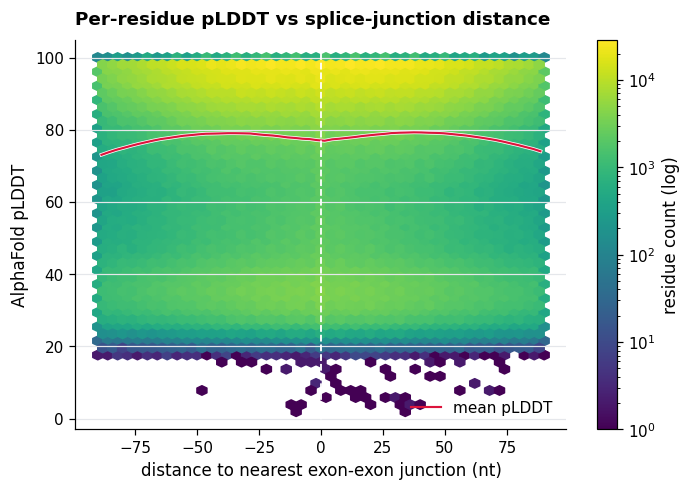

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
hb = ax.hexbin(dist, plddt, gridsize=45, bins="log", cmap="viridis",
               extent=(-WIN_NT, WIN_NT, float(plddt.min()), 100))
bins = np.arange(-WIN_NT, WIN_NT + 3, 3)
idx = np.digitize(dist, bins)
mean_pl = [plddt[idx == i].mean() if (idx == i).any() else np.nan
           for i in range(1, len(bins))]
ax.plot(bins[:-1] + 1.5, mean_pl, color="white", lw=2.4)
ax.plot(bins[:-1] + 1.5, mean_pl, color="crimson", lw=1.4, label="mean pLDDT")
ax.axvline(0, color="white", ls="--", lw=1.2)
ax.set_xlabel("distance to nearest exon-exon junction (nt)")
ax.set_ylabel("AlphaFold pLDDT")
ax.set_title("Per-residue pLDDT vs splice-junction distance", loc="left")
ax.legend(loc="lower right")
cb = fig.colorbar(hb, ax=ax); cb.set_label("residue count (log)")
from IPython.display import display
display(fig)
fig.savefig(DATA / "fig_analysis4_plddt.png", bbox_inches="tight")